Semana 2 Dia 2

Volatilidad historica, rolling y anualizada

[*********************100%***********************]  1 of 1 completed


Volatilidad histórica anualizada: 64.34%


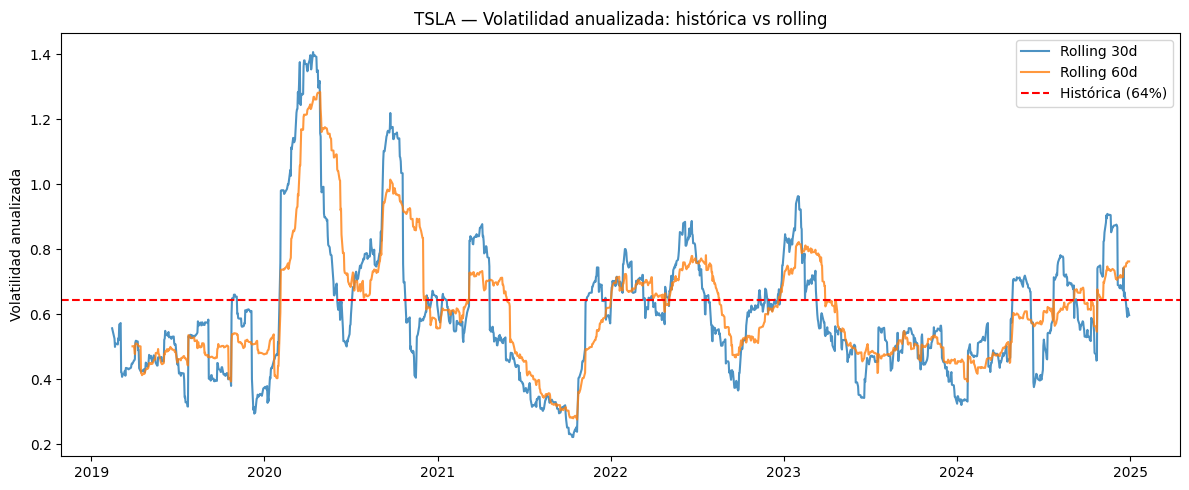


Fecha de máxima volatilidad rolling 30d: 2020-04-13 00:00:00
Volatilidad en ese punto: 140.7%


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

data = yf.download("TSLA", start="2019-01-01", end="2024-12-31")["Close"]
returns_tsla = np.log(data / data.shift(1)).dropna()

# Forzar a Series 1D si viene como DataFrame
if isinstance(returns_tsla, pd.DataFrame):
    returns_tsla = returns_tsla.squeeze()

vol_historica = returns_tsla.std() * np.sqrt(252)
print(f"Volatilidad histórica anualizada: {float(vol_historica)*100:.2f}%")

# 2. Volatilidad rolling (ventanas de 30 y 60 días)
vol_rolling_30 = returns_tsla.rolling(30).std() * np.sqrt(252)
vol_rolling_60 = returns_tsla.rolling(60).std() * np.sqrt(252)

# Gráfica
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(vol_rolling_30, label="Rolling 30d", alpha=0.8)
ax.plot(vol_rolling_60, label="Rolling 60d", alpha=0.8)
ax.axhline(vol_historica, color='red', linestyle='--', 
           label=f"Histórica ({vol_historica*100:.0f}%)")
ax.set_title("TSLA — Volatilidad anualizada: histórica vs rolling")
ax.set_ylabel("Volatilidad anualizada")
ax.legend()
plt.tight_layout()
plt.show()

# Identificar el período más volátil
fecha_max_vol = vol_rolling_30.idxmax()
print(f"\nFecha de máxima volatilidad rolling 30d: {fecha_max_vol}")
print(f"Volatilidad en ese punto: {vol_rolling_30.max()*100:.1f}%")